# Result Analysis

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import math

In [7]:
def load_json_to_df(json_path):
    with open(json_path) as file:
        data = json.load(file)
    df = pd.DataFrame(data=data["successful_experiments"])
    df.insert(0, "id", df.index + 1)
    return df

In [8]:
def plot_learning_curve(df, json_folder_path, exp_indexes, mode="loss", cols_limit=3):
    
    n_exp = len(exp_indexes)
    cols = min(cols_limit, n_exp)
    rows = math.ceil(n_exp / cols)

    all_values = []

    for exp_index in exp_indexes:
        exp_name = df.loc[df["id"] == exp_index, "exp_name"].values[0]
        json_path = f"{json_folder_path}\\{exp_name}.json"

        with open(json_path) as f:
            data = json.load(f)

        if mode == "loss":
            all_values += data["history"]["train_loss"]
            all_values += data["history"]["val_loss"]
        elif mode == "f1":
            all_values += data["history"]["train_f1"]
            all_values += data["history"]["val_f1"]

    y_min, y_max = min(all_values), max(all_values)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), sharey=True)
    axes = axes.flatten() if n_exp > 1 else [axes]

    for i, exp_index in enumerate(exp_indexes):

        ax = axes[i]

        exp_name = df.loc[df["id"] == exp_index, "exp_name"].values[0]
        json_path = f"{json_folder_path}\\{exp_name}.json"

        with open(json_path) as f:
            data = json.load(f)

        history = data["history"]
        train_loss = history["train_loss"]
        val_loss = history["val_loss"]
        train_f1 = history["train_f1"]
        val_f1 = history["val_f1"]
        best_epoch = history["best_epoch"]

        epochs = range(1, len(train_loss) + 1)

        if mode == "loss":
            ax.plot(epochs, train_loss, label="Train Loss")
            ax.plot(epochs, val_loss, label="Validation Loss")
            best_value = val_loss[best_epoch - 1]
        elif mode == "f1":
            ax.plot(epochs, train_f1, label="Train F1")
            ax.plot(epochs, val_f1, label="Validation F1")
            best_value = val_f1[best_epoch - 1]

        ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.6)
        ax.scatter(best_epoch, best_value, color="red", zorder=5)
        ax.text(best_epoch, best_value, f"  best={best_epoch}", color="red", va="bottom", ha="left")

        ax.set_title(exp_name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(mode.upper())
        ax.set_ylim(y_min, y_max)
        ax.grid(True)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

## Tuning Parameters (Data Type and LR)

### BERT

In [4]:
bert_tuning_path = r"D:\Dafa\Project\queryner-kd\result-data\tuning-bert\baseline-teacher-token-mean.json"
bert_tuning_folder_path = r"D:\Dafa\Project\queryner-kd\result-data\tuning-bert\json"

In [5]:
df_bert_tuning = load_json_to_df(bert_tuning_path)
df_bert_tuning["data_type"] = df_bert_tuning["exp_name"].apply(lambda x: x.split("_")[1])
df_bert_tuning["lr"] = df_bert_tuning["exp_name"].apply(lambda x: x.split("_")[2])
df_bert_tuning["crf_status"] = df_bert_tuning["exp_name"].apply(lambda x: x.split("_")[3])
df_bert_tuning.head()

,id,exp_name,val_f1,val_precision,val_recall,best_val_f1,test_f1,test_precision,test_recall,best_epoch,stopped_epoch,early_stopped,data_type,lr,crf_status
0,1,teacher_processed_1e-5_crf,0.733820,0.733820,0.733820,0.733820,0.658730,0.658730,0.658730,8,11,True,processed,1e-5,crf
1,2,teacher_processed_1e-5_nocrf,0.736041,0.736041,0.736041,0.743655,0.658456,0.658456,0.658456,7,10,True,processed,1e-5,nocrf
2,3,teacher_processed_2e-5_crf,0.730013,0.730013,0.730013,0.737944,0.664477,0.664477,0.664477,5,8,True,processed,2e-5,crf
3,4,teacher_processed_2e-5_nocrf,0.733185,0.733185,0.733185,0.733185,0.667214,0.667214,0.667214,5,8,True,processed,2e-5,nocrf
4,5,teacher_processed_5e-5_crf,0.726840,0.726840,0.726840,0.730013,0.653804,0.653804,0.653804,3,6,True,processed,5e-5,crf


data buat processed vs raw

In [6]:
df_bert_tuning[df_bert_tuning["lr"] == "1e-5"].groupby(["data_type"]).agg({"val_f1": "mean", "best_val_f1": "max"})

,val_f1,best_val_f1
data_type,,
processed,0.734930,0.743655
raw,0.734955,0.741037


data buat lr nya bert

In [115]:
df_bert_tuning[(df_bert_tuning["data_type"] == "processed")].groupby(["lr"]).agg({"val_f1": "mean", "best_val_f1": "max"})

,val_f1,best_val_f1
lr,,
1e-5,0.734930,0.743655
2e-5,0.731599,0.737944
5e-5,0.722398,0.731599


learning curve buat lr

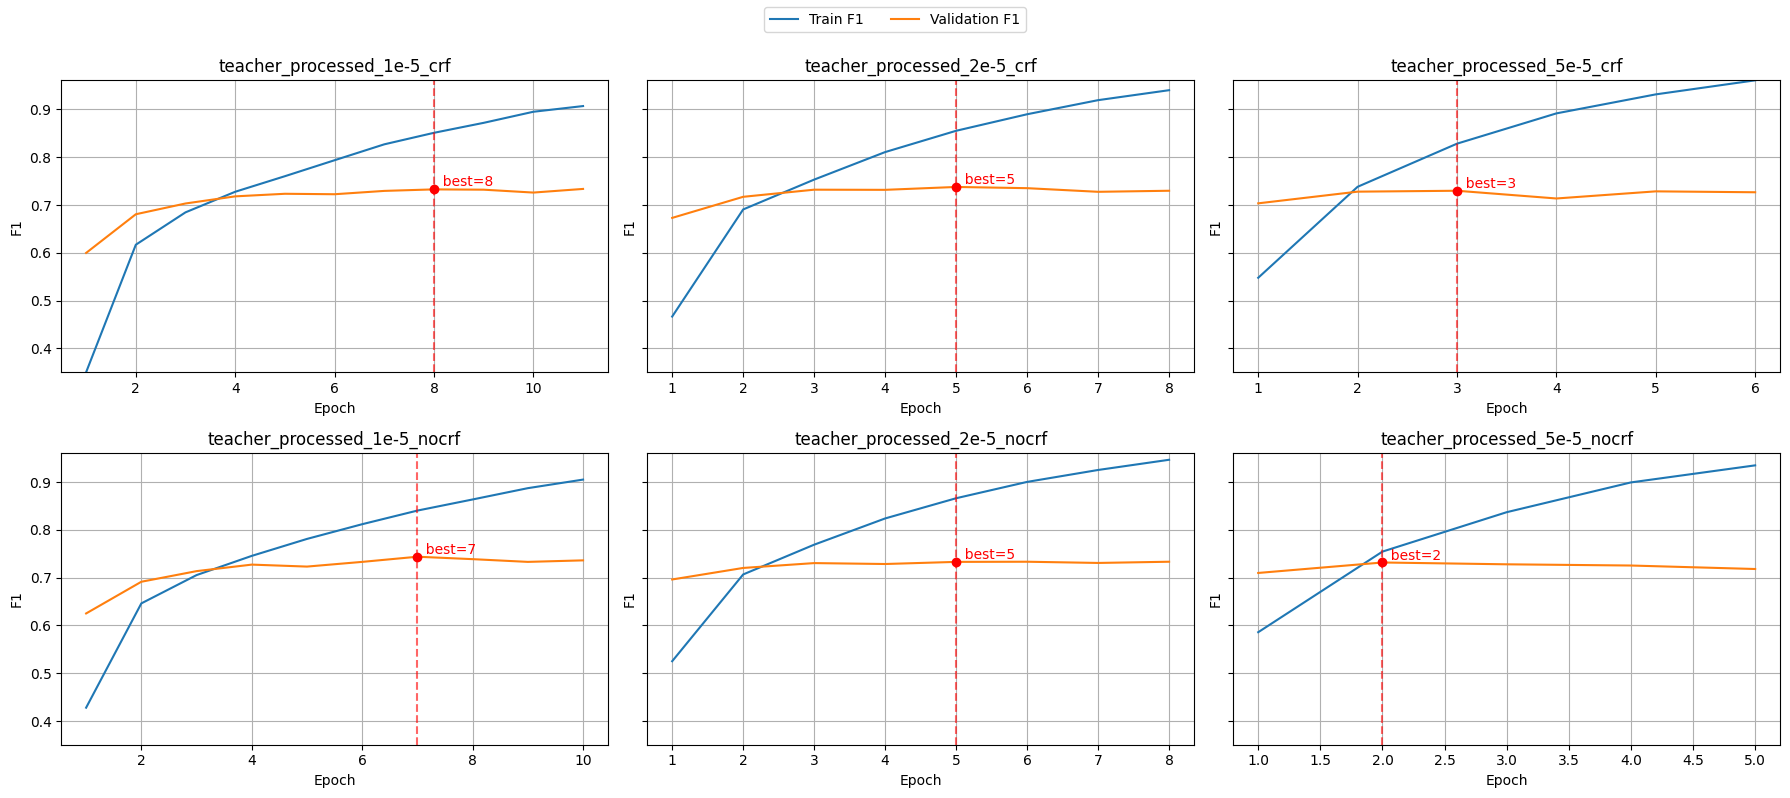

In [61]:
plot_learning_curve(df_bert_tuning, bert_tuning_folder_path, [1, 3, 5, 2, 4, 6], mode="f1")

### BiLSTM

In [116]:
bilstm_tuning_path = r"D:\Dafa\Project\queryner-kd\result-data\tuning-bilstm\baseline-student-bilstm-new.json"
bilstm_tuning_folder_path = r"D:\Dafa\Project\queryner-kd\result-data\tuning-bilstm\json"

df_bilstm_tuning = load_json_to_df(bilstm_tuning_path)
df_bilstm_tuning["data_type"] = df_bilstm_tuning["exp_name"].apply(lambda x: x.split("_")[1])
df_bilstm_tuning["lr"] = df_bilstm_tuning["exp_name"].apply(lambda x: x.split("_")[2])
df_bilstm_tuning["crf_status"] = df_bilstm_tuning["exp_name"].apply(lambda x: x.split("_")[3])
df_bilstm_tuning.head()

,id,exp_name,val_f1,val_precision,val_recall,best_val_f1,test_f1,test_precision,test_recall,best_epoch,stopped_epoch,early_stopped,data_type,lr,crf_status
0,1,bilstm_processed_5e-4_crf,0.649429,0.649429,0.649429,0.653871,0.592775,0.592775,0.592775,8,11,True,processed,5e-4,crf
1,2,bilstm_processed_5e-4_nocrf,0.654188,0.654188,0.654188,0.663071,0.590586,0.590586,0.590586,12,15,False,processed,5e-4,nocrf
2,3,bilstm_processed_1e-3_crf,0.650063,0.650063,0.650063,0.657678,0.587028,0.587028,0.587028,6,9,True,processed,1e-3,crf
3,4,bilstm_processed_1e-3_nocrf,0.643401,0.643401,0.643401,0.663388,0.600712,0.600712,0.600712,9,12,True,processed,1e-3,nocrf
4,5,bilstm_processed_2e-3_crf,0.637690,0.637690,0.637690,0.657360,0.579912,0.579912,0.579912,8,11,True,processed,2e-3,crf


In [118]:
df_bilstm_tuning[(df_bilstm_tuning["data_type"] == "processed")].groupby(["lr"]).agg({"val_f1": "mean", "best_val_f1": "max"})

,val_f1,best_val_f1
lr,,
1e-3,0.646732,0.663388
2e-3,0.650381,0.680520
3e-3,0.653553,0.665609
5e-4,0.651808,0.663071


In [69]:
df_bilstm_tuning.groupby(["crf_status"]).agg({"val_f1": "max", "test_f1": "max"})

,val_f1,test_f1
crf_status,,
crf,0.650063,0.592775
nocrf,0.663071,0.607006


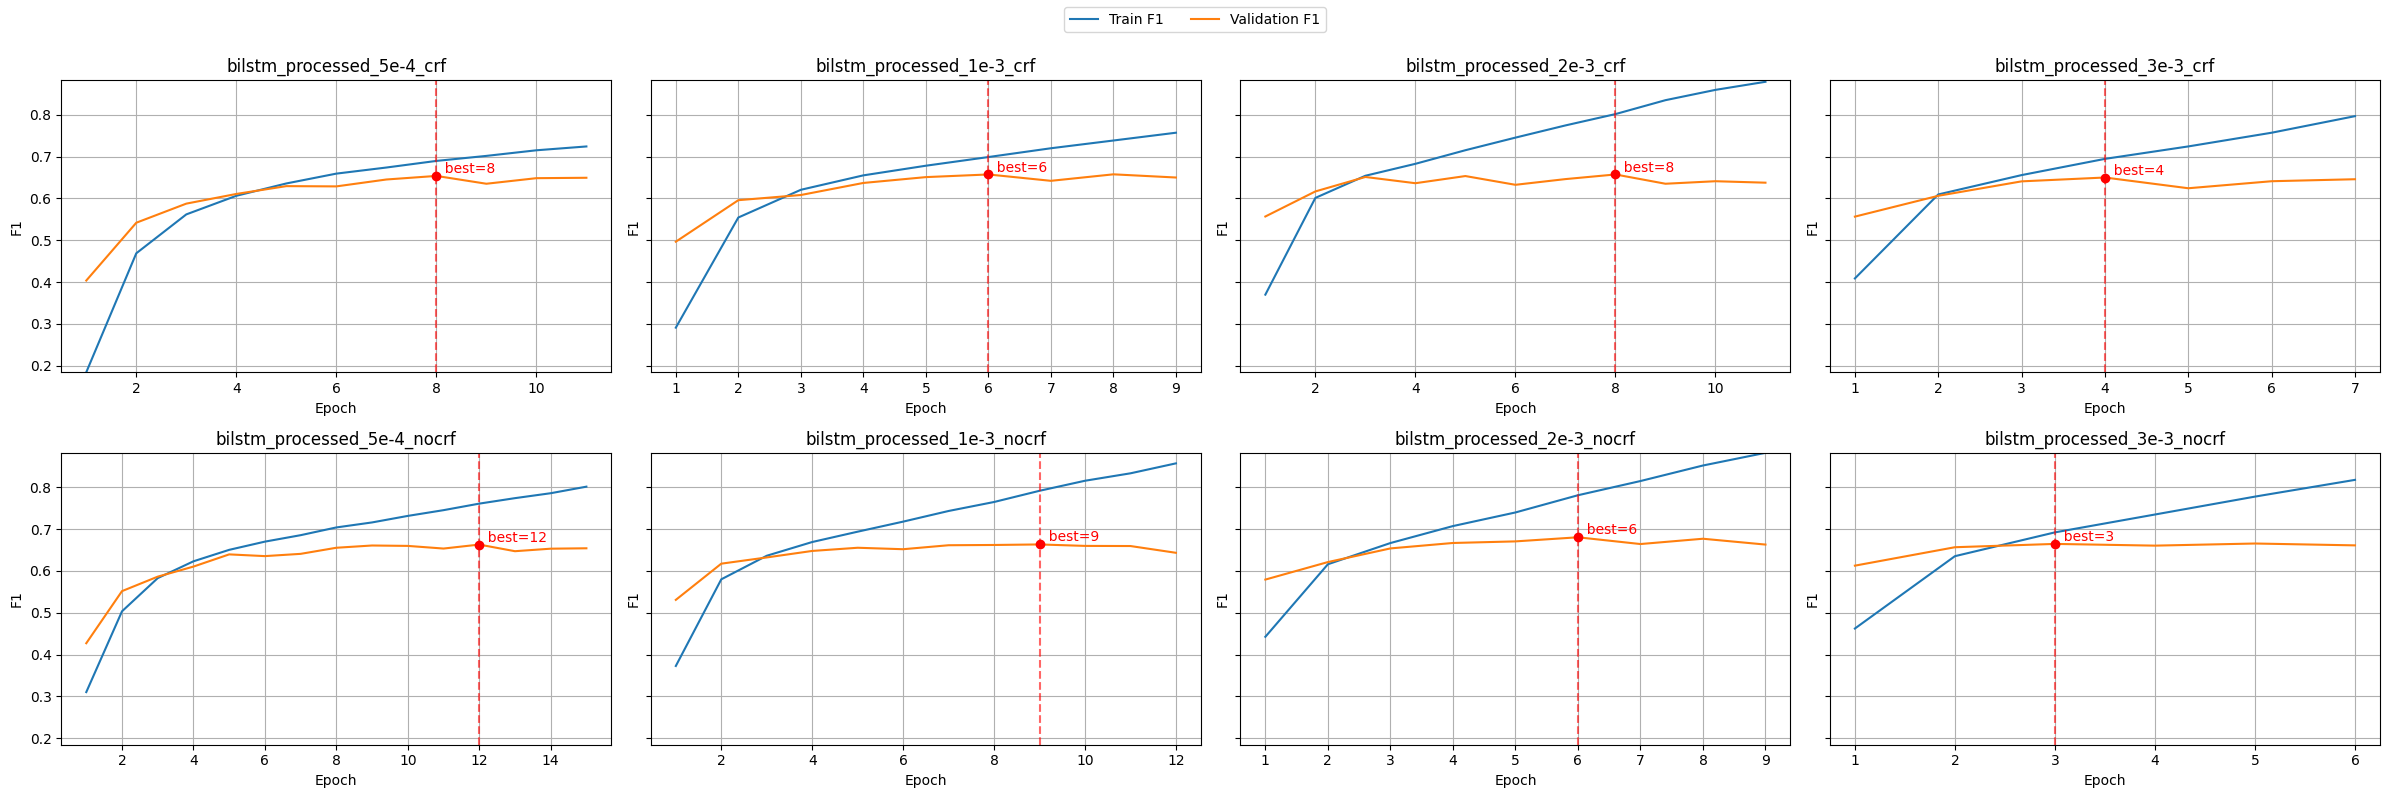

In [79]:
plot_learning_curve(df_bilstm_tuning, bilstm_tuning_folder_path, [1, 3, 5, 7, 2, 4, 6, 8], mode="f1", cols_limit=4)

## Model Baseline

In [7]:
baseline_teacher_path = r"D:\Dafa\Project\queryner-kd\result-data\baseline\teacher\baseline-teacher-token-mean.json"
baseline_student_bert_path = r"D:\Dafa\Project\queryner-kd\result-data\baseline\student\baseline-student-bert-1e5.json"
baseline_student_bilstm_path = r"D:\Dafa\Project\queryner-kd\result-data\baseline\student\baseline-student-bilstm.json"

In [16]:
df_base_teacher = load_json_to_df(baseline_teacher_path)
df_base_teacher = df_base_teacher[(df_base_teacher["exp_name"] == "teacher_processed_1e-5_nocrf") | (df_base_teacher["exp_name"] == "teacher_processed_1e-5_crf")]

df_base_student_bert = load_json_to_df(baseline_student_bert_path)
df_base_student_bilstm = load_json_to_df(baseline_student_bilstm_path)
df_baseline = pd.concat([df_base_teacher, df_base_student_bert, df_base_student_bilstm], ignore_index=True)

df_baseline["model_name"] = df_baseline["exp_name"].apply(lambda x: x.split("_")[0])
df_baseline["crf_status"] = df_baseline["exp_name"].apply(lambda x: x.split("_")[-1])

In [20]:
df_baseline_crf = df_baseline[df_baseline["crf_status"] == "crf"]
df_baseline_nocrf = df_baseline[df_baseline["crf_status"] == "nocrf"]

display(df_baseline)

,id,exp_name,val_f1,val_precision,val_recall,best_val_f1,test_f1,test_precision,test_recall,best_epoch,stopped_epoch,early_stopped,model_name,crf_status
0,1,teacher_processed_1e-5_crf,0.733820,0.733820,0.733820,0.733820,0.658730,0.658730,0.658730,8,11,True,teacher,crf
1,2,teacher_processed_1e-5_nocrf,0.736041,0.736041,0.736041,0.743655,0.658456,0.658456,0.658456,7,10,True,teacher,nocrf
2,1,distilbert_processed_1e-5_crf,0.719226,0.719226,0.719226,0.722716,0.654625,0.654625,0.654625,8,10,True,distilbert,crf
3,2,distilbert_processed_1e-5_nocrf,0.710977,0.710977,0.710977,0.711294,0.659825,0.659825,0.659825,5,7,True,distilbert,nocrf
4,3,tinybert_processed_1e-5_crf,0.666561,0.666561,0.666561,0.666561,0.607553,0.607553,0.607553,15,15,False,tinybert,crf
5,4,tinybert_processed_1e-5_nocrf,0.674492,0.674492,0.674492,0.675444,0.614122,0.614122,0.614122,12,14,True,tinybert,nocrf
6,1,bilstm_processed_2e-3_crf,0.637690,0.637690,0.637690,0.657360,0.579912,0.579912,0.579912,8,11,True,bilstm,crf
7,2,bilstm_processed_2e-3_nocrf,0.663071,0.663071,0.663071,0.680520,0.607006,0.607006,0.607006,6,9,True,bilstm,nocrf


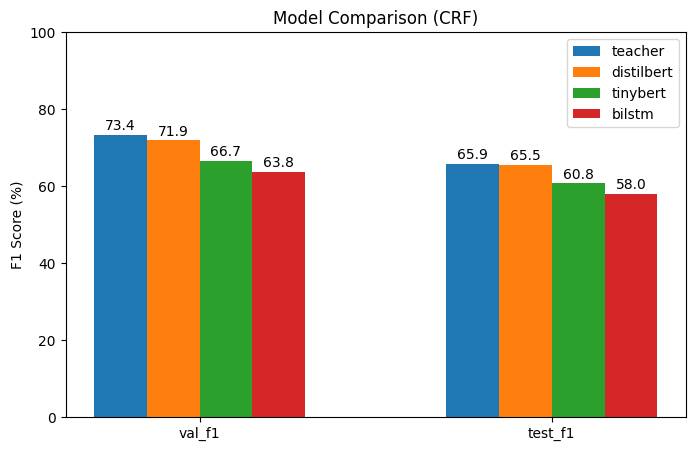

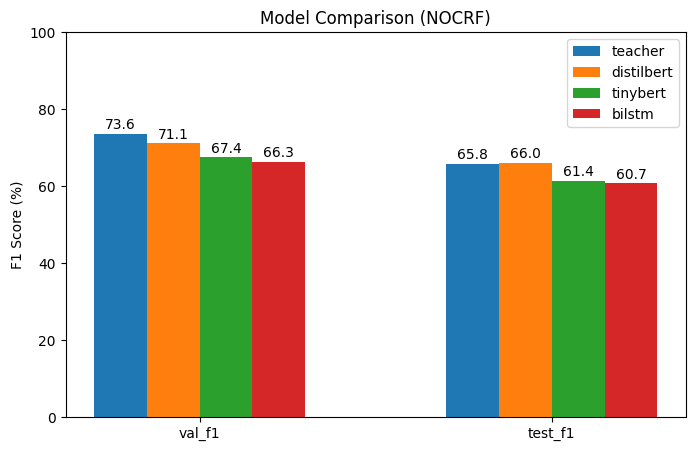

In [28]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["val_f1", "test_f1"]
models = ["teacher", "distilbert", "tinybert", "bilstm"]

def plot_group(df_baseline, crf_status):

    subset = df_baseline[df_baseline["crf_status"] == crf_status]

    x = np.arange(len(metrics))
    width = 0.15

    plt.figure(figsize=(8,5))

    for i, model in enumerate(models):

        row = subset[subset["model_name"] == model].iloc[0]

        scores = [
            row["val_f1"] * 100,
            row["test_f1"] * 100
        ]

        bars = plt.bar(x + i*width - 1.5*width, scores, width, label=model)

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.5,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.xticks(x, metrics)
    plt.ylim(0,100)

    plt.ylabel("F1 Score (%)")
    plt.title(f"Model Comparison ({crf_status.upper()})")
    plt.legend()

    plt.show()


plot_group(df_baseline, "crf")
plot_group(df_baseline, "nocrf")

## KD

In [2]:
file_path = r"D:\Dafa\Project\queryner-kd\result-data\kd-v3\summary.json"

In [9]:
df = load_json_to_df(file_path)
df.head()

,id,exp_name,teacher,student,crf_combo,alpha,beta,temperature,val_f1,best_val_f1,test_f1,best_epoch,stopped_epoch,early_stopped
0,1,KD_teacher_crf_distilbert_both_crf_alpha0.5_be...,teacher_crf,distilbert,both_crf,0.5,0.5,2.0,0.726523,0.730330,0.656541,13,15,False
1,2,KD_teacher_crf_distilbert_both_crf_alpha0.5_be...,teacher_crf,distilbert,both_crf,0.5,0.5,4.0,0.723668,0.723985,0.660920,8,10,True
2,3,KD_teacher_crf_distilbert_both_crf_alpha0.7_be...,teacher_crf,distilbert,both_crf,0.7,0.3,2.0,0.718591,0.718591,0.659278,8,10,True
3,4,KD_teacher_crf_distilbert_both_crf_alpha0.7_be...,teacher_crf,distilbert,both_crf,0.7,0.3,4.0,0.725888,0.725888,0.657635,7,9,True
4,5,KD_teacher_crf_distilbert_teacher_crf_alpha0.5...,teacher_crf,distilbert,teacher_crf,0.5,0.5,2.0,0.724302,0.724619,0.656267,7,9,True


In [10]:
df.groupby(["student"]).agg({"val_f1": "max", "best_val_f1": "max", "test_f1": "max"})

,val_f1,best_val_f1,test_f1
student,,,
bilstm,0.654822,0.655774,0.577997
distilbert,0.732234,0.736041,0.663930
tinybert,0.685279,0.685279,0.629174


In [11]:
df.groupby(["student"]).agg({"val_f1": "mean", "best_val_f1": "mean", "test_f1": "mean"})

,val_f1,best_val_f1,test_f1
student,,,
bilstm,0.630446,0.632879,0.564769
distilbert,0.725254,0.726946,0.658776
tinybert,0.669760,0.669945,0.616721


In [12]:
df.groupby(["temperature"]).agg({"val_f1": "mean", "best_val_f1": "mean", "test_f1": "mean"}).sort_values(by="test_f1", ascending=False)

,val_f1,best_val_f1,test_f1
temperature,,,
4.0,0.676290,0.677189,0.614426
2.0,0.674016,0.675991,0.612419


In [13]:
df.groupby(["alpha", "beta"]).agg({"val_f1": "mean", "best_val_f1": "mean", "test_f1": "mean"}).sort_values(by="test_f1", ascending=False)

,,val_f1,best_val_f1,test_f1
alpha,beta,,,
0.7,0.3,0.675197,0.675709,0.613483
0.5,0.5,0.675109,0.677471,0.613361


In [14]:
df.groupby(["crf_combo"]).agg({"val_f1": "mean", "best_val_f1": "mean", "test_f1": "mean"}).sort_values(by="test_f1", ascending=False)

,val_f1,best_val_f1,test_f1
crf_combo,,,
both_nocrf,0.683402,0.684698,0.619823
both_crf,0.669919,0.671320,0.610359
teacher_crf,0.672139,0.673752,0.610085


In [28]:
df[df["student"] == "bilstm"].sort_values(by="test_f1", ascending=False).head(9)

,id,exp_name,teacher,student,crf_combo,alpha,beta,temperature,val_f1,best_val_f1,test_f1,best_epoch,stopped_epoch,early_stopped
32,33,KD_teacher_nocrf_bilstm_both_nocrf_alpha0.5_be...,teacher_nocrf,bilstm,both_nocrf,0.5,0.5,2.0,0.639911,0.642449,0.577997,6,8,True
34,35,KD_teacher_nocrf_bilstm_both_nocrf_alpha0.7_be...,teacher_nocrf,bilstm,both_nocrf,0.7,0.3,2.0,0.654822,0.655774,0.576902,5,7,True
35,36,KD_teacher_nocrf_bilstm_both_nocrf_alpha0.7_be...,teacher_nocrf,bilstm,both_nocrf,0.7,0.3,4.0,0.641497,0.641497,0.575807,6,8,True
21,22,KD_teacher_crf_bilstm_teacher_crf_alpha0.5_bet...,teacher_crf,bilstm,teacher_crf,0.5,0.5,4.0,0.634201,0.635152,0.569513,9,11,True
20,21,KD_teacher_crf_bilstm_teacher_crf_alpha0.5_bet...,teacher_crf,bilstm,teacher_crf,0.5,0.5,2.0,0.623096,0.632614,0.565408,10,12,True
33,34,KD_teacher_nocrf_bilstm_both_nocrf_alpha0.5_be...,teacher_nocrf,bilstm,both_nocrf,0.5,0.5,4.0,0.639277,0.639277,0.565134,4,6,True
18,19,KD_teacher_crf_bilstm_both_crf_alpha0.7_beta0....,teacher_crf,bilstm,both_crf,0.7,0.3,2.0,0.626269,0.626269,0.561576,6,8,True
19,20,KD_teacher_crf_bilstm_both_crf_alpha0.7_beta0....,teacher_crf,bilstm,both_crf,0.7,0.3,4.0,0.636104,0.638959,0.560482,9,11,True
17,18,KD_teacher_crf_bilstm_both_crf_alpha0.5_beta0....,teacher_crf,bilstm,both_crf,0.5,0.5,4.0,0.619289,0.624683,0.558566,9,11,True


In [29]:
id_list = [26, 2, 32, 12, 33, 19]

In [31]:
df_filtered = df[df["id"].isin(id_list)][["id","student", "crf_combo", "alpha", "beta", "temperature", "best_val_f1", "val_f1", "test_f1"]]
df_filtered.head(6)

,id,student,crf_combo,alpha,beta,temperature,best_val_f1,val_f1,test_f1
1,2,distilbert,both_crf,0.5,0.5,4.0,0.723985,0.723668,0.660920
11,12,tinybert,both_crf,0.7,0.3,4.0,0.665926,0.665926,0.619048
18,19,bilstm,both_crf,0.7,0.3,2.0,0.626269,0.626269,0.561576
25,26,distilbert,both_nocrf,0.5,0.5,4.0,0.728109,0.727157,0.663930
31,32,tinybert,both_nocrf,0.7,0.3,4.0,0.680203,0.680203,0.629174
32,33,bilstm,both_nocrf,0.5,0.5,2.0,0.642449,0.639911,0.577997


In [32]:
get_json_path_from_id(26)
get_json_path_from_id(2)

get_json_path_from_id(32)
get_json_path_from_id(12)

get_json_path_from_id(33)
get_json_path_from_id(19)

D:\Dafa\Project\queryner-kd\result-data\kd-v3\json\KD_teacher_nocrf_distilbert_both_nocrf_alpha0.5_beta0.5_temp4.json
D:\Dafa\Project\queryner-kd\result-data\kd-v3\json\KD_teacher_crf_distilbert_both_crf_alpha0.5_beta0.5_temp4.json
D:\Dafa\Project\queryner-kd\result-data\kd-v3\json\KD_teacher_nocrf_tinybert_both_nocrf_alpha0.7_beta0.3_temp4.json
D:\Dafa\Project\queryner-kd\result-data\kd-v3\json\KD_teacher_crf_tinybert_both_crf_alpha0.7_beta0.3_temp4.json
D:\Dafa\Project\queryner-kd\result-data\kd-v3\json\KD_teacher_nocrf_bilstm_both_nocrf_alpha0.5_beta0.5_temp2.json
D:\Dafa\Project\queryner-kd\result-data\kd-v3\json\KD_teacher_crf_bilstm_both_crf_alpha0.7_beta0.3_temp2.json


In [46]:
import pandas as pd

# ---------------------------
# BASELINE (HARDCODE)
# ---------------------------
baseline = {
    "distilbert": {
        "crf": {"best_val_f1": 0.7227, "val_f1": 0.7192},
        "nocrf": {"best_val_f1": 0.7113, "val_f1": 0.7110},
    },
    "tinybert": {
        "crf": {"best_val_f1": 0.6666, "val_f1": 0.6666},
        "nocrf": {"best_val_f1": 0.6754, "val_f1": 0.6745},
    },
    "bilstm": {
        "crf": {"best_val_f1": 0.6574, "val_f1": 0.6377},
        "nocrf": {"best_val_f1": 0.6805, "val_f1": 0.6631},
    }
}

# ---------------------------
# FUNCTION: DETECT CRF TYPE
# ---------------------------
def detect_crf_type(crf_combo):
    """
    menentukan apakah model student menggunakan CRF
    """
    if "nocrf" in crf_combo:
        return "nocrf"
    return "crf"


# ---------------------------
# FUNCTION: COMPARE TO BASELINE
# ---------------------------
def compare_to_baseline(df, baseline, baseline_type="best_val_f1"):
    """
    baseline_type: 'best_val_f1' atau 'val_f1'
    """
    
    records = []

    for _, row in df.iterrows():
        student = row["student"].lower()
        crf_type = detect_crf_type(row["crf_combo"])
        test_f1 = row[baseline_type]

        base = baseline[student][crf_type][baseline_type]

        if test_f1 > base:
            result = "better"
        else:
            result = "worse"

        records.append({
            "student": student,
            "crf_type": crf_type,
            "result": result
        })

    comp_df = pd.DataFrame(records)

    summary = (
        comp_df
        .groupby(["student", "crf_type", "result"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    return summary


# ---------------------------
# RUN COMPARISON
# ---------------------------
table_best = compare_to_baseline(df, baseline, baseline_type="best_val_f1")
table_avg  = compare_to_baseline(df, baseline, baseline_type="val_f1")

print("=== Comparison vs BEST baseline ===")
print(table_best)

print("\n=== Comparison vs AVG baseline ===")
print(table_avg)

=== Comparison vs BEST baseline ===
result     student crf_type  better  worse
0           bilstm      crf       0      8
1           bilstm    nocrf       0      4
2       distilbert      crf       6      2
3       distilbert    nocrf       4      0
4         tinybert      crf       3      5
5         tinybert    nocrf       3      1

=== Comparison vs AVG baseline ===
result     student crf_type  better  worse
0           bilstm      crf       0      8
1           bilstm    nocrf       0      4
2       distilbert      crf       7      1
3       distilbert    nocrf       4      0
4         tinybert      crf       3      5
5         tinybert    nocrf       3      1


### Show training curve

In [32]:
import matplotlib.pyplot as plt

In [33]:
json_detail_path = r"D:\Dafa\Project\queryner-kd\result-data\kd-v3\json"

def get_json_path_from_id(exp_id):
    return f"{json_detail_path}\\{df[df['id'] == exp_id]['exp_name'].values[0]}.json"

def show_training_curve(json_path):
    with open(json_path) as file:
        data = json.load(file)
    train_loss = data["history"]["train_loss"]
    val_loss = data["history"]["val_loss"]
    train_f1 = data["history"]["train_f1"]
    val_f1 = data["history"]["val_f1"]

    epochs = range(1, len(train_loss) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_f1, label='Train F1')
    plt.plot(epochs, val_f1, label='Validation F1')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.title('Training and Validation F1 Score')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [35]:
import json
import matplotlib.pyplot as plt

json_detail_path = r"D:\Dafa\Project\queryner-kd\result-data\kd-v3\json"

def get_json_path_from_id(exp_id):
    return f"{json_detail_path}\\{df[df['id'] == exp_id]['exp_name'].values[0]}.json"


def show_training_curve(exp_id):
    
    json_path = get_json_path_from_id(exp_id)
    
    with open(json_path) as file:
        data = json.load(file)
    
    history = data["history"]
    
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    train_f1 = history["train_f1"]
    val_f1 = history["val_f1"]
    best_epoch = history["best_epoch"]

    epochs = range(1, len(train_loss) + 1)

    # --- LOSS ---
    best_loss = val_loss[best_epoch - 1]
    
    # --- F1 ---
    best_f1 = val_f1[best_epoch - 1]

    plt.figure(figsize=(12, 5))

    # ================= LOSS =================
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')

    plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.6)
    plt.scatter(best_epoch, best_loss, color="red", zorder=5)
    plt.text(best_epoch, best_loss, f"  best={best_epoch}", color="red", va="bottom")

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # ================= F1 =================
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_f1, label='Train F1')
    plt.plot(epochs, val_f1, label='Validation F1')

    plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.6)
    plt.scatter(best_epoch, best_f1, color="red", zorder=5)
    plt.text(best_epoch, best_f1, f"  best={best_epoch}", color="red", va="bottom")

    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('Training and Validation F1 Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

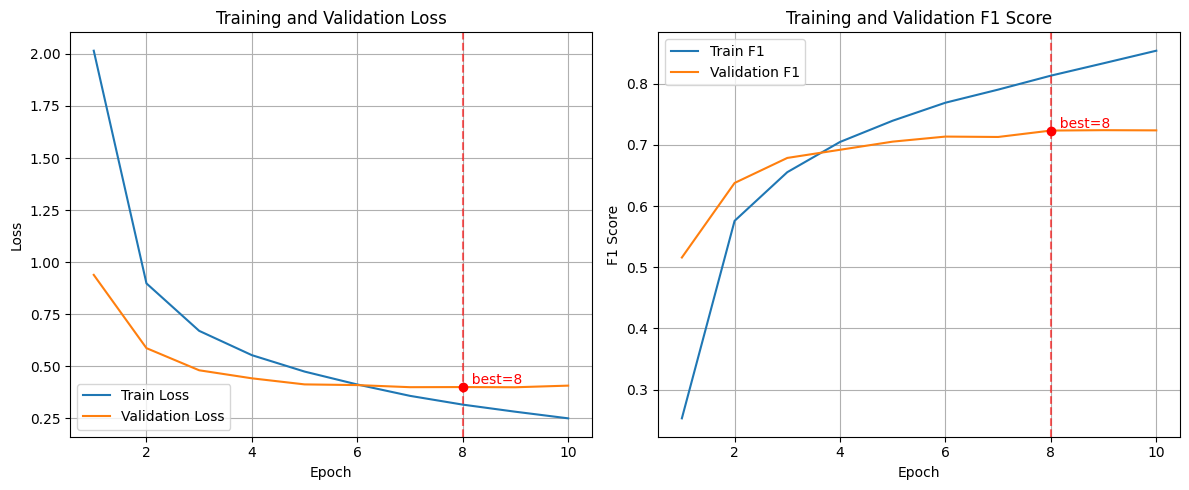

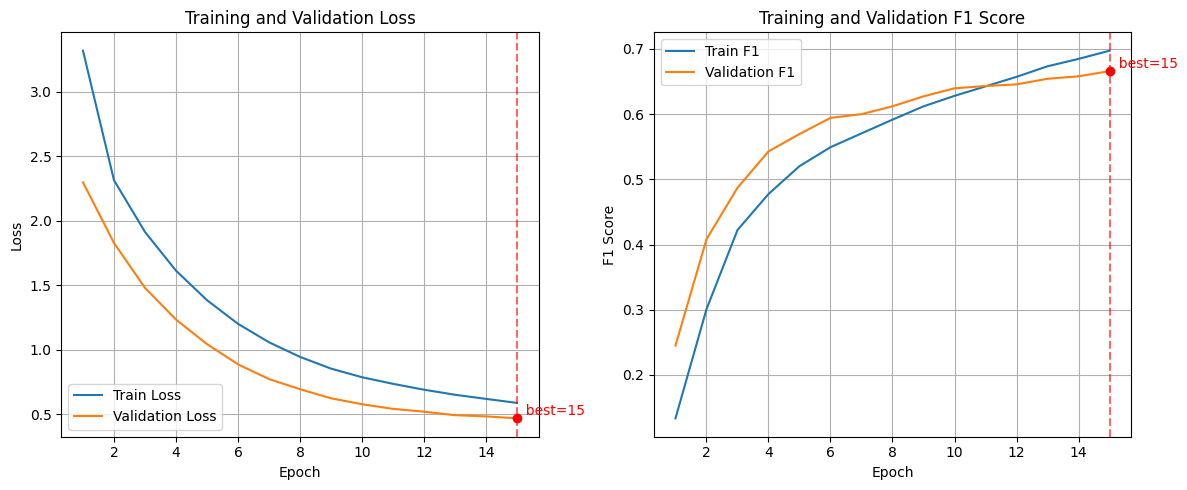

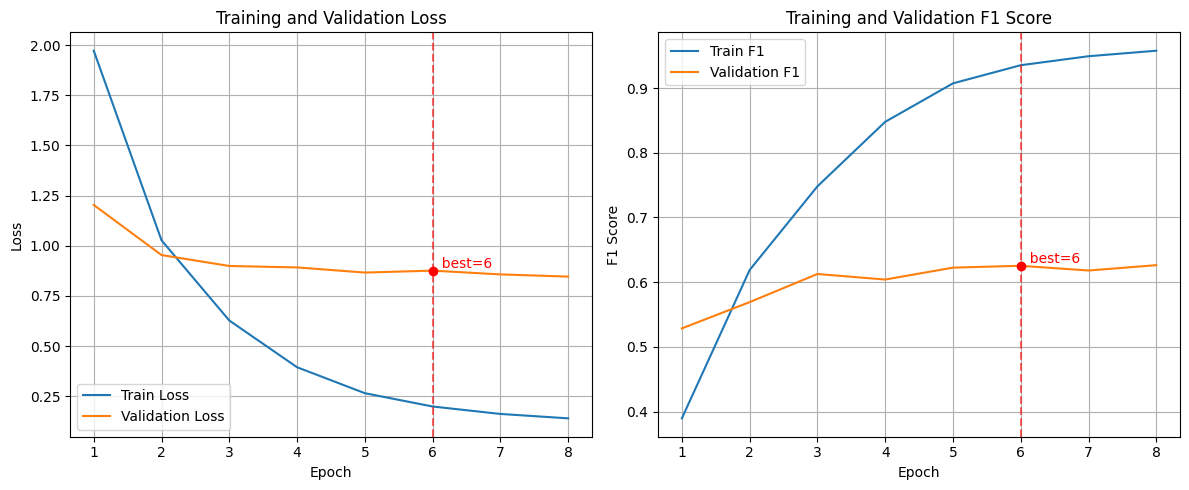

In [37]:
show_training_curve(2)
show_training_curve(12)
show_training_curve(19)

## Efisiensi

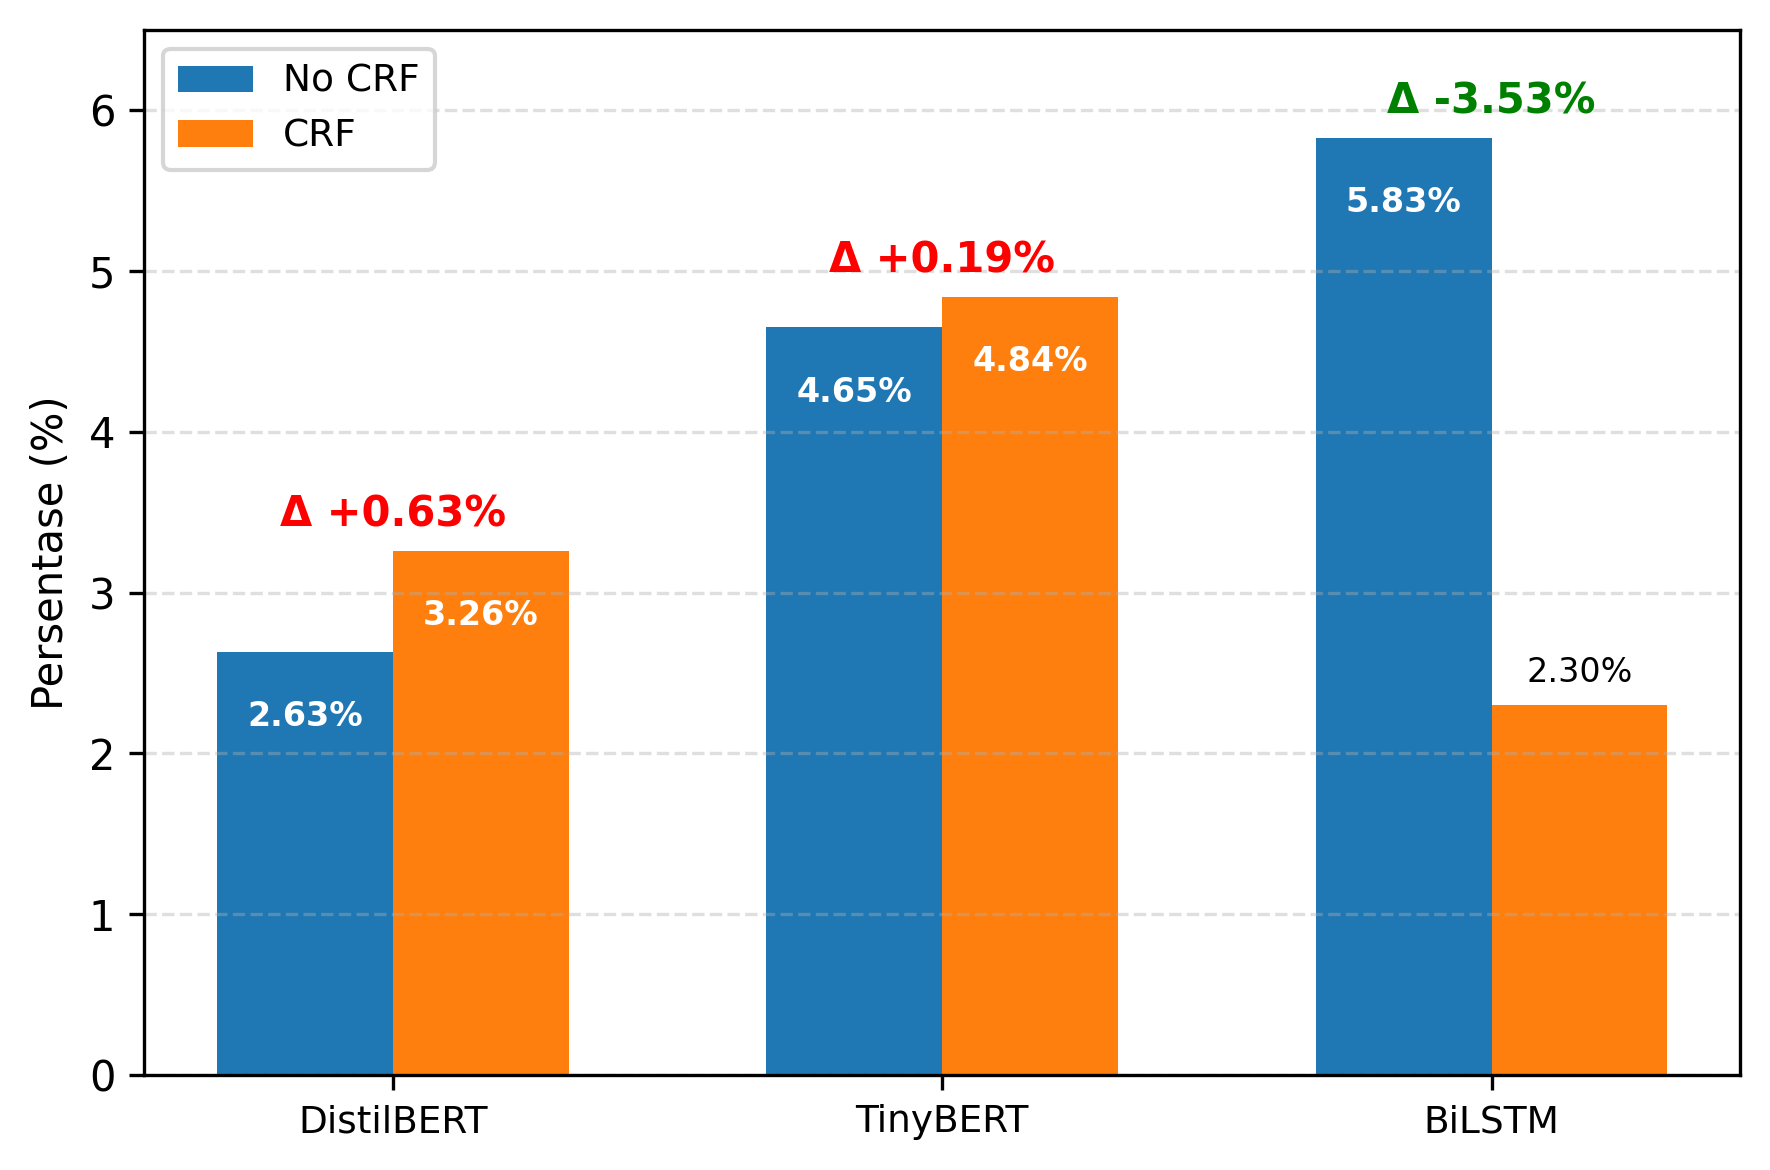

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["DistilBERT", "TinyBERT", "BiLSTM"]
no_crf = [2.63, 4.65, 5.83]
crf = [3.26, 4.84, 2.30]
delta = [0.63, 0.19, -3.53]

x = np.arange(len(models))
width = 0.32

plt.figure(figsize=(6, 4), dpi=300)

# Bars
bars1 = plt.bar(x - width/2, no_crf, width, label="No CRF")
bars2 = plt.bar(x + width/2, crf, width, label="CRF")

# === LABEL DALAM BAR ===
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        
        # kalau terlalu kecil, pindah ke atas biar tetap kebaca
        if height < 2.5:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1,
                f"{height:.2f}%",
                ha='center',
                va='bottom',
                fontsize=8,
                color='black'
            )
        else:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height - 0.3,
                f"{height:.2f}%",
                ha='center',
                va='top',
                fontsize=8,
                color='white',
                fontweight='bold'
            )

add_labels(bars1)
add_labels(bars2)

# === DELTA ===
for i in range(len(models)):
    y_max = max(no_crf[i], crf[i])
    color = "red" if delta[i] > 0 else "green"
    
    plt.text(
        x[i], 
        y_max + 0.15, 
        f"Δ {delta[i]:+.2f}%", 
        ha='center', 
        fontsize=10, 
        fontweight='bold',
        color=color
    )

# Labels
plt.xticks(x, models, fontsize=9)
plt.ylabel("Persentase (%)", fontsize=10)
plt.ylim(0, 6.5)

plt.legend(fontsize=9, loc="best")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

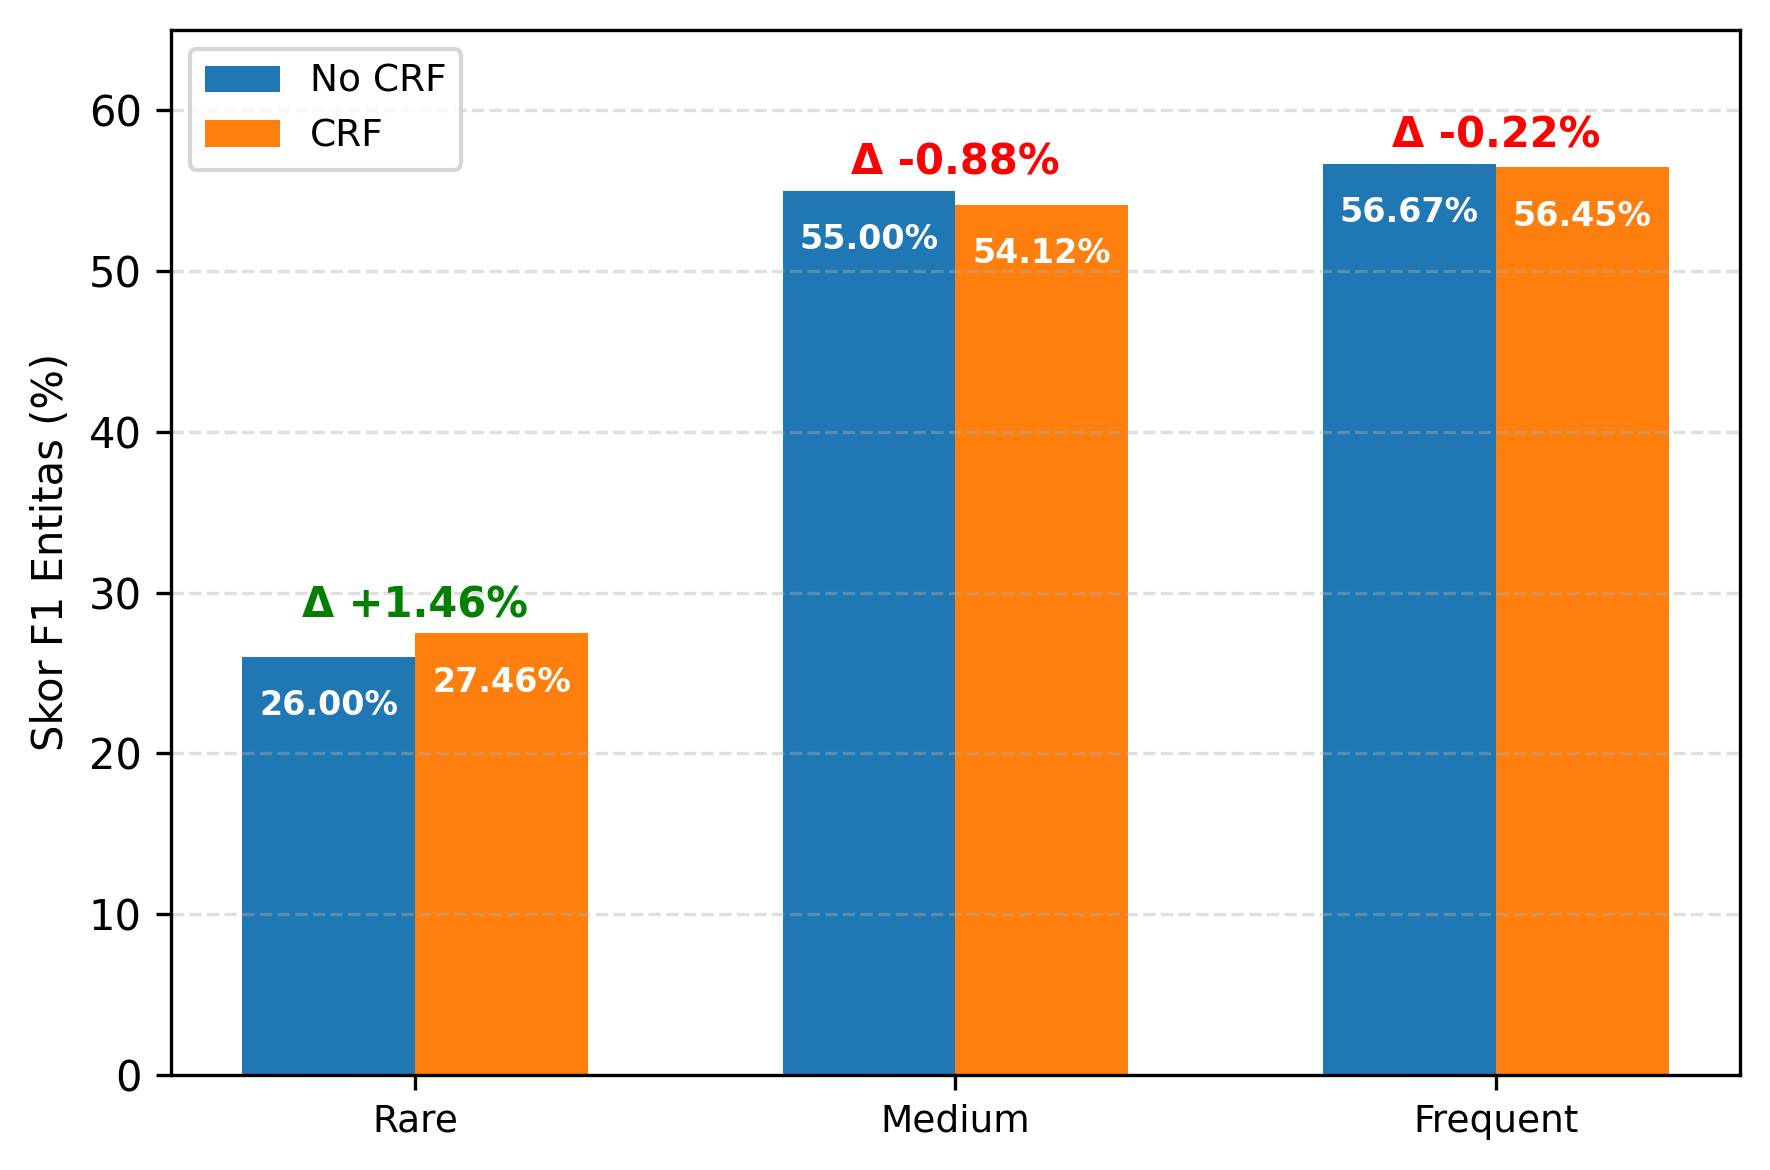

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Data (sesuai tabel)
categories = ["Rare", "Medium", "Frequent"]
no_crf = [26.00, 55.00, 56.67]
crf = [27.46, 54.12, 56.45]
delta = [1.46, -0.88, -0.22]

x = np.arange(len(categories))
width = 0.32

plt.figure(figsize=(6, 4), dpi=300)

# Bars
bars1 = plt.bar(x - width/2, no_crf, width, label="No CRF")
bars2 = plt.bar(x + width/2, crf, width, label="CRF")

# === LABEL DALAM BAR ===
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        
        if height < 10:  # threshold disesuaikan (karena skala sekarang lebih besar)
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.5,
                f"{height:.2f}%",
                ha='center',
                va='bottom',
                fontsize=8,
                color='black'
            )
        else:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height - 2,
                f"{height:.2f}%",
                ha='center',
                va='top',
                fontsize=8,
                color='white',
                fontweight='bold'
            )

add_labels(bars1)
add_labels(bars2)

# === DELTA ===
for i in range(len(categories)):
    y_max = max(no_crf[i], crf[i])
    color = "red" if delta[i] < 0 else "green"
    
    plt.text(
        x[i], 
        y_max + 1, 
        f"Δ {delta[i]:+.2f}%", 
        ha='center', 
        fontsize=10, 
        fontweight='bold',
        color=color
    )

# Labels
plt.xticks(x, categories, fontsize=9)
plt.ylabel("Skor F1 Entitas (%)", fontsize=10)
plt.ylim(0, 65)

plt.legend(fontsize=9, loc="best")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()